# 04 · Experience, pay, and AI use among US developers (Stack Overflow survey microdata, 2021–2025)

**Question.** This is the only source here with **individual experience and pay**. Among US professional developers, did the pay gap between junior (0–2 years) and senior (10+ years) developers widen after ChatGPT? Did the share of juniors fall? How does AI-tool use vary with experience?

**Data.** Stack Overflow Annual Developer Survey microdata, 2021–2025 (ODbL). Each survey is fielded around May, so 2021 and 2022 are pre-ChatGPT and 2023–2025 are post.

**Sample.** Respondents who are developers by profession, live in the United States, and are employed (full-time where the question allows).

**Experience measures.**
- `YearsCodePro`: years coding professionally, asked 2021–2024.
- `WorkExp`: years of work experience, asked 2022–2025.

The two measures are analyzed separately because neither spans all five years.

**Caveats.** This is an opt-in convenience sample. The mix of respondents changes with Stack Overflow's recruitment each year, pay is self-reported, and no survey weights exist. The results describe survey respondents, not the US developer labor market.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from common import *
set_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

In [2]:
COLS = ["MainBranch", "Employment", "Country", "YearsCodePro", "WorkExp", "ConvertedCompYearly",
        "OrgSize", "RemoteWork", "AISelect", "AIThreat", "ICorPM"]

def load_so(year):
    path = RAW / "stackoverflow" / "microdata" / str(year) / "results.csv"
    have = pd.read_csv(path, nrows=0).columns
    df = pd.read_csv(path, usecols=[c for c in COLS if c in have], low_memory=False)
    return df.assign(year=year)

so = pd.concat([load_so(y) for y in range(2021, 2026)], ignore_index=True)
print(so.groupby("year").size().rename("respondents").to_string())
print(so[so.Country.astype(str).str.contains("United States")].groupby("year").Country.unique().to_string())

year
2021    83439
2022    73268
2023    89184
2024    65437
2025    49191
year
2021    [United States of America]
2022    [United States of America]
2023    [United States of America]
2024    [United States of America]
2025    [United States of America]


In [3]:
def parse_years(s):
    s = s.astype("string").replace({"Less than 1 year": "0.5", "More than 50 years": "51"})
    return pd.to_numeric(s, errors="coerce")

BAND_LABELS = ["0-2 yrs", "3-5 yrs", "6-9 yrs", "10+ yrs"]
def to_band(x):
    return pd.cut(x, bins=[-0.1, 2, 5, 9, 100], labels=BAND_LABELS)

so["yrs_pro"] = parse_years(so.YearsCodePro)
so["work_exp"] = pd.to_numeric(so.WorkExp, errors="coerce")
so["band_pro"], so["band_work"] = to_band(so.yrs_pro), to_band(so.work_exp)

empl = so.Employment.astype("string").fillna("")
us = so[(so.MainBranch == "I am a developer by profession")
        & (so.Country == "United States of America")
        & empl.str.contains("Employed") & ~empl.str.contains("part-time")].copy()
us["comp"] = us.ConvertedCompYearly
us["comp_ok"] = us.comp.between(20_000, 1_000_000)
us["log_comp"] = np.log(us.comp.where(us.comp_ok))

print(pd.DataFrame({
    "US prof. employed": us.groupby("year").size(),
    "with pay in [20k, 1M]": us[us.comp_ok].groupby("year").size(),
    "with YearsCodePro": us.groupby("year").yrs_pro.count(),
    "with WorkExp": us.groupby("year").work_exp.count(),
}).to_string())

      US prof. employed  with pay in [20k, 1M]  with YearsCodePro  with WorkExp
year                                                                           
2021               9664                   8008               9581             0
2022               8967                   7125               8805          6176
2023              12418                  10251              12215          8401
2024               7091                   3882               7060          4795
2025               4558                   3836                  0          4507


## 1. Experience composition of respondents

Share of respondents by experience band (%), YearsCodePro


band_pro,0-2 yrs,3-5 yrs,6-9 yrs,10+ yrs
year,,,,
2021,12.8,21.5,19.1,46.5
2022,11.6,19.0,19.9,49.5
2023,10.0,16.7,19.8,53.5
2024,9.4,15.0,19.5,56.1


Share of respondents by experience band (%), WorkExp


band_work,0-2 yrs,3-5 yrs,6-9 yrs,10+ yrs
year,,,,
2022,8.4,16.2,18.6,56.7
2023,7.8,14.9,18.1,59.3
2024,6.6,13.3,18.5,61.6
2025,5.0,10.6,16.3,68.1


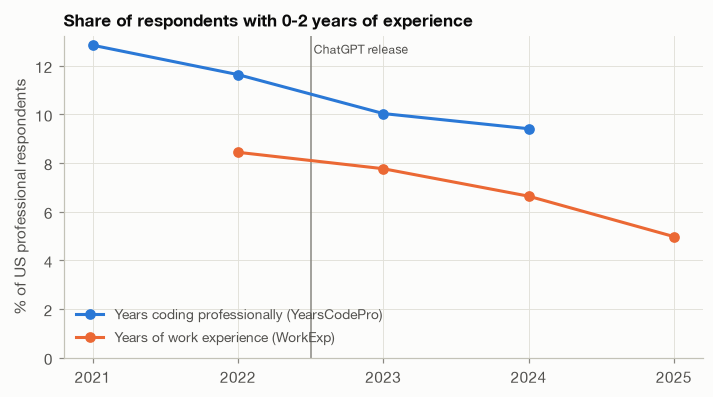

In [4]:
def shares(band):
    t = us.dropna(subset=[band]).groupby("year")[band].value_counts(normalize=True).unstack() * 100
    return t[BAND_LABELS]
comp_pro, comp_work = shares("band_pro"), shares("band_work")
print("Share of respondents by experience band (%), YearsCodePro"); display(comp_pro.round(1))
print("Share of respondents by experience band (%), WorkExp"); display(comp_work.round(1))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for t, lab, c in [(comp_pro, "Years coding professionally (YearsCodePro)", BLUE), (comp_work, "Years of work experience (WorkExp)", ORANGE)]:
    ax.plot(t.index, t["0-2 yrs"], color=c, marker="o", label=lab)
mark_chatgpt(ax, x=2022.5)
ax.set_xticks(range(2021, 2026))
ax.set_ylim(0, None)
ax.set_ylabel("% of US professional respondents")
ax.set_title("Share of respondents with 0-2 years of experience")
ax.legend(loc="lower left")
save(fig, "04_so_junior_share");

## 2. Median pay by experience band

Median pay ($k), YearsCodePro bands


band_pro,0-2 yrs,3-5 yrs,6-9 yrs,10+ yrs
year,,,,
2021,80.0,105.0,130.0,146.0
2022,90.0,120.0,144.1,160.0
2023,92.0,125.0,152.5,170.0
2024,90.0,115.0,145.0,170.0


Median pay ($k), WorkExp bands


band_work,0-2 yrs,3-5 yrs,6-9 yrs,10+ yrs
year,,,,
2022,90.0,120.0,140.0,153.0
2023,90.0,120.0,150.0,165.0
2024,90.0,115.0,140.0,165.0
2025,90.0,105.0,145.0,170.0


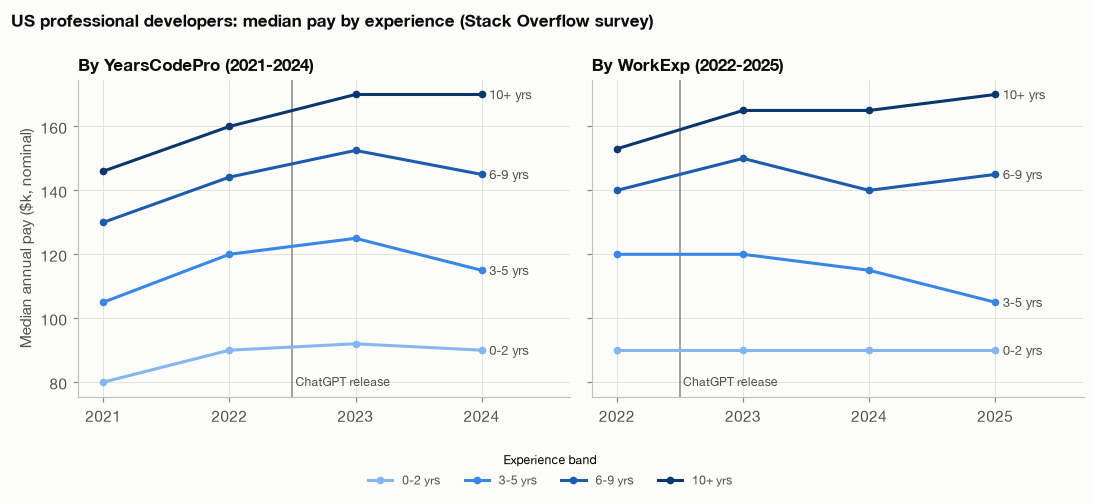

In [5]:
def med(band):
    return us[us.comp_ok].dropna(subset=[band]).groupby(["year", band], observed=True).comp.median().unstack()[BAND_LABELS] / 1000
med_pro, med_work = med("band_pro"), med("band_work")
print("Median pay ($k), YearsCodePro bands"); display(med_pro.round(1))
print("Median pay ($k), WorkExp bands"); display(med_work.round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, t, title in [(axes[0], med_pro, "By YearsCodePro (2021-2024)"), (axes[1], med_work, "By WorkExp (2022-2025)")]:
    for b, c in zip(BAND_LABELS, ORDINAL_BLUE):
        ax.plot(t.index, t[b], color=c, marker="o", ms=4, label=b)
        label_end(ax, t.index[-1], t[b].iloc[-1], b)
    mark_chatgpt(ax, x=2022.5, y=0.07)
    ax.set_xticks(t.index)
    ax.set_xlim(t.index[0] - 0.2, t.index[-1] + 0.7)
    ax.set_title(title)
axes[0].set_ylabel("Median annual pay ($k, nominal)")
fig.suptitle("US professional developers: median pay by experience (Stack Overflow survey)", x=0.01, ha="left",
             fontweight="bold", fontsize=11, color=INK)
fig.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=4, title="Experience band",
           fontsize=8, title_fontsize=8)
save(fig, "04_so_median_pay_by_experience");

## 3. Junior–senior pay gap: DiD and year-by-year estimates

Sample: juniors (0–2 years) and seniors (10+ years) only.

- **DiD:** $\log \text{pay}_i = \beta_1 \text{Junior}_i + \gamma_{\text{year}} + \beta_3(\text{Junior}_i \times \text{Post}_t) + [\text{org size FE}] + \varepsilon_i$, with HC3 standard errors.
- **Event study:** Junior × year dummies, with 2022 as the reference year.

$\beta_3 < 0$ would mean the junior pay gap widened after ChatGPT.

In [6]:
def jr_sr(band, years):
    d = us[us.comp_ok & us.year.isin(years) & us[band].isin(["0-2 yrs", "10+ yrs"])].copy()
    d["junior"] = (d[band] == "0-2 yrs").astype(float)
    d["post"] = (d.year >= 2023).astype(float)
    d["jr_post"] = d.junior * d.post
    d["OrgSize"] = d.OrgSize.fillna("missing")
    return d

samples = {"YearsCodePro, 2021-2024": jr_sr("band_pro", range(2021, 2025)),
           "WorkExp, 2022-2025": jr_sr("band_work", range(2022, 2026))}
rows = {}
for name, d in samples.items():
    for ctrl, f in [("year FE", "log_comp ~ junior + jr_post + C(year)"),
                    ("year FE + org size", "log_comp ~ junior + jr_post + C(year) + C(OrgSize)")]:
        m = smf.ols(f, data=d).fit(cov_type="HC3")
        rows[(name, ctrl)] = {"junior (pre gap)": m.params.junior, "junior x post": m.params.jr_post,
                              "se": m.bse.jr_post, "p": m.pvalues.jr_post,
                              "pct change in gap": np.expm1(m.params.jr_post) * 100, "n": int(m.nobs)}
so_did = pd.DataFrame(rows).T
so_did.round(3)

junior (pre gap)  junior x post     se      p  pct change in gap        n
YearsCodePro, 2021-2024 year FE                       -0.544         -0.052  0.017  0.002             -5.077  17597.0
                        year FE + org size            -0.540         -0.057  0.016  0.001             -5.517  17597.0
WorkExp, 2022-2025      year FE                       -0.471         -0.138  0.029  0.000            -12.913  12751.0
                        year FE + org size            -0.477         -0.136  0.028  0.000            -12.679  12751.0

YearsCodePro, 2021-2024        WorkExp, 2022-2025       
                        coef     se               coef     se
2021                  -0.033  0.025                NaN    NaN
2022                   0.000  0.000              0.000  0.000
2023                  -0.058  0.023             -0.122  0.031
2024                  -0.101  0.029             -0.118  0.039
2025                     NaN    NaN             -0.205  0.041

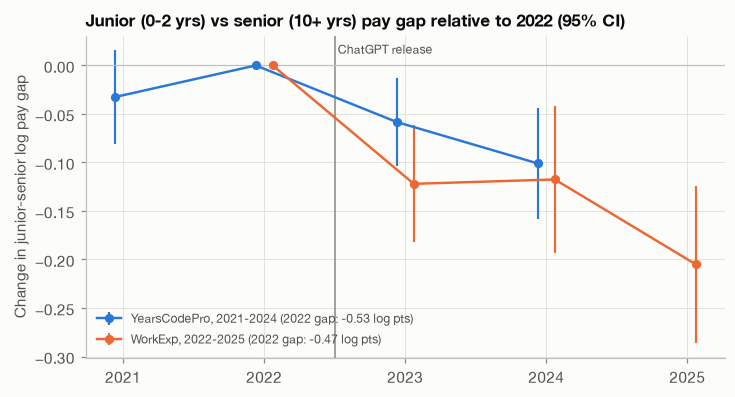

In [7]:
def jr_event(d, ref=2022):
    d = d.copy(); terms = []
    for y in sorted(d.year.unique()):
        if y != ref:
            d[f"jx{y}"] = d.junior * (d.year == y); terms.append(f"jx{y}")
    m = smf.ols(f"log_comp ~ junior + {' + '.join(terms)} + C(year)", data=d).fit(cov_type="HC3")
    out = pd.DataFrame({"coef": m.params[terms], "se": m.bse[terms]}, index=terms)
    out.index = [int(t[2:]) for t in terms]
    out.loc[ref] = [0.0, 0.0]
    return out.sort_index(), m.params.junior

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ev = {}
for (name, d), c, off in zip(samples.items(), [BLUE, ORANGE], [-0.06, 0.06]):
    e, base_gap = jr_event(d)
    ev[name] = e
    ax.errorbar(e.index + off, e.coef, yerr=1.96 * e.se, color=c, marker="o", ms=5, lw=1.6,
                elinewidth=1.4, capsize=0, label=f"{name} (2022 gap: {base_gap:+.2f} log pts)")
ax.axhline(0, color=BASELINE, lw=0.8)
mark_chatgpt(ax, x=2022.5)
ax.set_xticks(range(2021, 2026))
ax.set_ylabel("Change in junior-senior log pay gap")
ax.set_title("Junior (0-2 yrs) vs senior (10+ yrs) pay gap relative to 2022 (95% CI)")
ax.legend(loc="lower left", fontsize=8)
save(fig, "04_so_junior_senior_gap_event_study")
pd.concat(ev, axis=1).round(3)

## 4. AI-tool use and perceived threat by experience

Share using AI tools in their development process (%), by WorkExp band


year,2023,2024,2025
band_work,,,
0-2 yrs,49.7,66.0,77.9
3-5 yrs,42.9,62.3,76.9
6-9 yrs,38.7,58.2,77.0
10+ yrs,36.5,55.1,76.0


2025: share using AI tools DAILY (%)


band_work,0-2 yrs,3-5 yrs,6-9 yrs,10+ yrs
daily %,41.9,40.7,42.4,44.1


Share who say AI is a threat to their current job (%)


year,2024,2025
band_work,,
0-2 yrs,10.1,13.4
3-5 yrs,10.3,13.5
6-9 yrs,9.6,13.6
10+ yrs,10.0,16.3


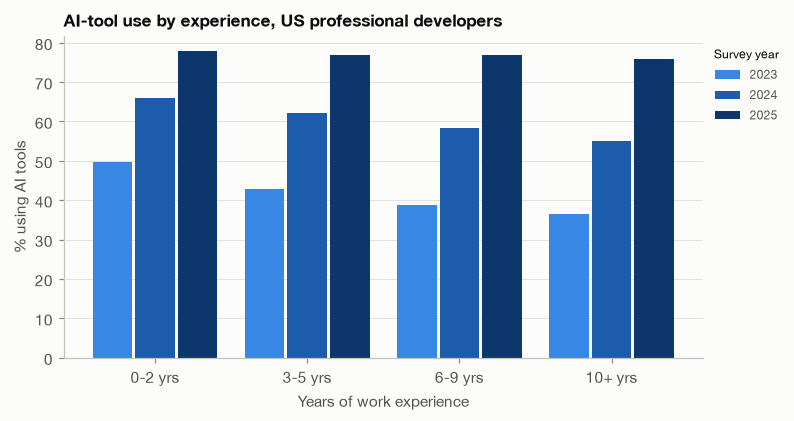

In [8]:
ai = us[(us.year >= 2023)].dropna(subset=["band_work", "AISelect"]).copy()
ai["uses_ai"] = ai.AISelect.astype(str).str.startswith("Yes")
ai_use = ai.groupby(["band_work", "year"], observed=True).uses_ai.mean().unstack() * 100
print("Share using AI tools in their development process (%), by WorkExp band"); display(ai_use.round(1))

daily = ai[ai.year == 2025].assign(daily=lambda d: d.AISelect.eq("Yes, I use AI tools daily"))
print("2025: share using AI tools DAILY (%)")
display((daily.groupby("band_work", observed=True).daily.mean() * 100).round(1).to_frame("daily %").T)

th = us[us.year >= 2024].dropna(subset=["band_work", "AIThreat"])
threat = th.groupby(["band_work", "year"], observed=True).AIThreat.apply(lambda s: (s == "Yes").mean() * 100).unstack()
print("Share who say AI is a threat to their current job (%)"); display(threat.round(1))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
xpos = np.arange(len(BAND_LABELS)); w = 0.26
for i, (y, c) in enumerate(zip(ai_use.columns, ORDINAL_BLUE[1:])):
    ax.bar(xpos + (i - 1) * (w + 0.02), ai_use[y], width=w, color=c, label=str(y))
ax.set_xticks(xpos, BAND_LABELS)
ax.grid(axis="x", visible=False)
ax.set_ylabel("% using AI tools")
ax.set_xlabel("Years of work experience")
ax.set_title("AI-tool use by experience, US professional developers")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), title="Survey year", fontsize=8, title_fontsize=8)
save(fig, "04_so_ai_use_by_experience");

In [9]:
keep = ["year", "yrs_pro", "work_exp", "band_pro", "band_work", "comp", "comp_ok", "OrgSize", "AISelect", "AIThreat"]
us[keep].to_csv(PROCESSED / "stackoverflow_us_professional.csv.gz", index=False)
so_did.to_csv(PROCESSED / "stackoverflow_junior_senior_did.csv")
print("saved", len(us), "rows")

saved 42698 rows


## Findings

1. **Juniors are a shrinking share of respondents.**
   - 0–2 years coding professionally: 12.8% (2021) → 11.6% (2022) → 10.0% (2023) → 9.4% (2024).
   - 0–2 years of work experience: 8.4% (2022) → 7.8% → 6.6% → 5.0% (2025).
   - The decline started before ChatGPT (2021→22) and may partly reflect who answers the survey, not only who gets hired.
2. **Junior pay stalled while senior pay rose.**
   - WorkExp bands: median pay for 0–2-year developers was flat at $90k from 2022 to 2025, while 10+-year developers rose from $153k to $170k.
   - YearsCodePro bands over 2022–24: $90k → $90k for juniors, $160k → $170k for seniors.
3. **The junior–senior pay gap widened after 2022.**
   - Difference-in-differences (juniors vs 10+ years): **junior × post = −0.052 (SE 0.017, p = 0.002)** for YearsCodePro 2021–24, and **−0.138 (SE 0.029)** for WorkExp 2022–25. That is a 5–13% relative widening, and org-size controls do not change it.
   - Year by year, the gap widens relative to 2022: −0.06 and −0.10 (YearsCodePro, 2023–24); −0.12, −0.12 and −0.21 (WorkExp, 2023–25).
   - The only pre-period estimate (2021: −0.03, SE 0.025, not significant) means the gap was, if anything, *wider* in 2021 and *narrowing* into 2022. The post-2022 widening is not a continuation of a pre-trend.
4. **Juniors adopted AI tools first, and adoption has since converged.**
   - In 2023, 50% of 0–2-year developers used AI tools, versus 37% of 10+-year developers. By 2025 it was 78% versus 76%, with similar daily use (42% vs 44%).
   - The share who see AI as a threat to their job rose from about 10% (2024) to 13–16% (2025), highest among seniors.

**Interpretation.** Of the sources here, this is the closest match to the paper's hypothesis, and it points the same way: after 2022, junior developers' self-reported pay fell relative to seniors'. The magnitude is uncertain. The sample is opt-in and changes every year, and junior cells are small (about 5–10% of respondents). Selection could also produce this pattern: if big-tech new-graduate hiring fell, the juniors still in the sample would skew toward lower-paying firms.